In [ ]:
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

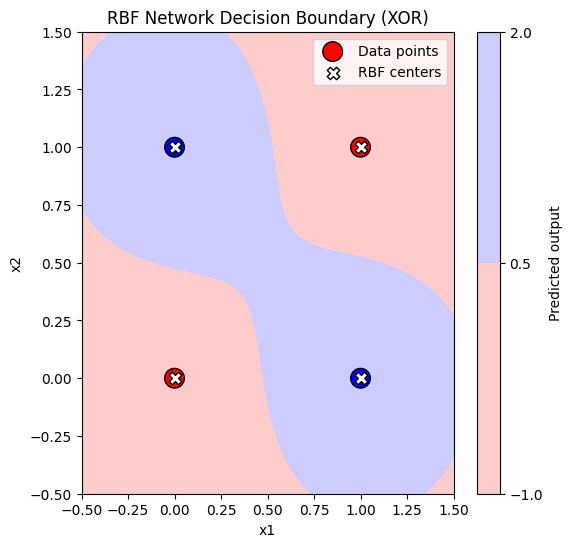

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# --- Step 1: Inputs and outputs ---
X = np.array([(0,0),(0,1),(1,0),(1,1)])
y = np.array([0,1,1,0])

# --- Step 2: RBF function ---
def rbf(x, c, sigma=0.5):
    x, c = np.array(x), np.array(c)
    dist_sq = np.linalg.norm(x - c)**2
    return np.exp(-dist_sq / (2 * sigma**2))

# --- Step 3: Find centers using KMeans ---
n_centers = 4
kmeans = KMeans(n_clusters=n_centers, n_init=10)
kmeans.fit(X)
centers = kmeans.cluster_centers_

# --- Step 4: Build hidden layer matrix Φ ---
Phi = np.zeros((len(X), n_centers))
for i, val in enumerate(X):
    for j, c in enumerate(centers):
        Phi[i, j] = rbf(val, c)

# --- Step 5: Compute optimal weights ---
w = np.linalg.pinv(Phi).dot(y)

# --- Step 6: Prediction function ---
def predict(x):
    phi_x = np.array([rbf(x, c) for c in centers])
    return phi_x.dot(w)

# --- Step 7: Create grid for visualization ---
x1_range = np.linspace(-0.5, 1.5, 200)
x2_range = np.linspace(-0.5, 1.5, 200)
xx, yy = np.meshgrid(x1_range, x2_range)
zz = np.zeros_like(xx)

for i in range(xx.shape[0]):
    for j in range(xx.shape[1]):
        zz[i, j] = predict([xx[i, j], yy[i, j]])

# --- Step 8: Plot decision boundary and data ---
plt.figure(figsize=(6,6))
plt.contourf(xx, yy, zz, levels=[-1, 0.5, 2], colors=['#ffcccc','#ccccff'])
plt.colorbar(label='Predicted output')

# Original data points
colors = ['red' if label == 0 else 'blue' for label in y]
plt.scatter(X[:,0], X[:,1], c=colors, s=200, edgecolor='black', label='Data points')

# RBF centers
plt.scatter(centers[:,0], centers[:,1], c='white', s=80, marker='X', edgecolor='black', label='RBF centers')

plt.title("RBF Network Decision Boundary (XOR)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.show()
